,Modelo,DE-COP,SimMIA
0,Llama-3.1-8B,0.77565,0.5201
1,Llama-3.3-70B,0.86815,0.5679


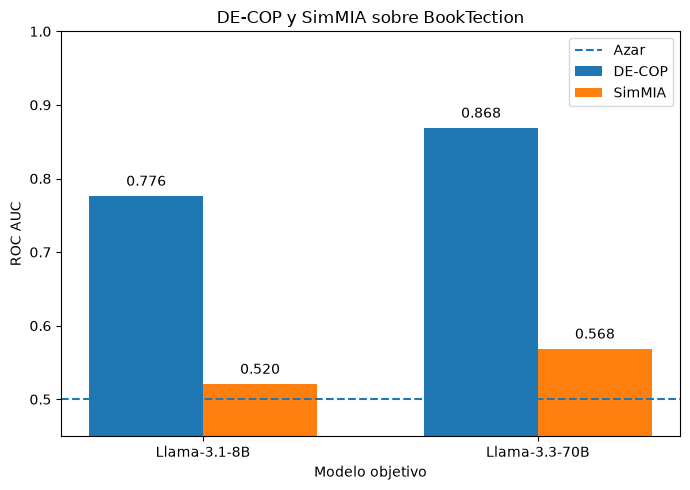

PNG: /Users/florenciazoffi/Desktop/code/sietesemestre/nlp/NLP_Proyecto_Final/simmia_decop/figures/auc_booktection_decop_vs_simmia.png
PDF: /Users/florenciazoffi/Desktop/code/sietesemestre/nlp/NLP_Proyecto_Final/simmia_decop/figures/auc_booktection_decop_vs_simmia.pdf


In [17]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Directorios
# ---------------------------------------------------------

BASE_DIR = Path.cwd().parent
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = BASE_DIR / "figures"

FIGURES_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# Cargar métricas
# ---------------------------------------------------------

decop_70 = pd.read_csv(
    RESULTS_DIR
    / "decop"
    / "llama-3.3-70b-versatile"
    / "decop_metrics_summary.csv"
).iloc[0]

decop_8 = pd.read_csv(
    RESULTS_DIR
    / "decop"
    / "llama-3.1-8b-instant"
    / "decop_metrics_summary.csv"
).iloc[0]

simmia_70 = pd.read_csv(
    RESULTS_DIR
    / "simmia"
    / "llama-3.3-70b-versatile"
    / "simmia_metrics_summary.csv"
).iloc[0]

simmia_8 = pd.read_csv(
    RESULTS_DIR
    / "simmia"
    / "llama-3.1-8b-instant"
    / "simmia_metrics_summary.csv"
).iloc[0]

# ---------------------------------------------------------
# Tabla resumen
# ---------------------------------------------------------

summary = pd.DataFrame([
    {
        "Modelo": "Llama-3.1-8B",
        "DE-COP": float(decop_8["auc"]),
        "SimMIA": float(simmia_8["auc"]),
    },
    {
        "Modelo": "Llama-3.3-70B",
        "DE-COP": float(decop_70["auc"]),
        "SimMIA": float(simmia_70["auc"]),
    },
])

display(summary)

summary.to_csv(
    FIGURES_DIR / "booktection_methods_summary.csv",
    index=False,
)

# ---------------------------------------------------------
# Gráfico
# ---------------------------------------------------------

models = summary["Modelo"]

decop_auc = summary["DE-COP"]
simmia_auc = summary["SimMIA"]

x = np.arange(len(models))
width = 0.34

fig, ax = plt.subplots(figsize=(7,5))

bars1 = ax.bar(
    x - width/2,
    decop_auc,
    width,
    label="DE-COP",
)

bars2 = ax.bar(
    x + width/2,
    simmia_auc,
    width,
    label="SimMIA",
)

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    label="Azar",
)

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.set_ylabel("ROC AUC")
ax.set_xlabel("Modelo objetivo")
ax.set_title("DE-COP y SimMIA sobre BookTection")
ax.set_ylim(0.45,1.0)

ax.legend()

# Etiquetas encima de cada barra
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

plt.tight_layout()

png_path = FIGURES_DIR / "auc_booktection_decop_vs_simmia.png"
pdf_path = FIGURES_DIR / "auc_booktection_decop_vs_simmia.pdf"

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

plt.show()

print("PNG:", png_path)
print("PDF:", pdf_path)

,Modelo,DE-COP,SimMIA
0,Llama-3.1-8B,0.3575,0.494606
1,Llama-3.3-70B,0.2850,0.481854


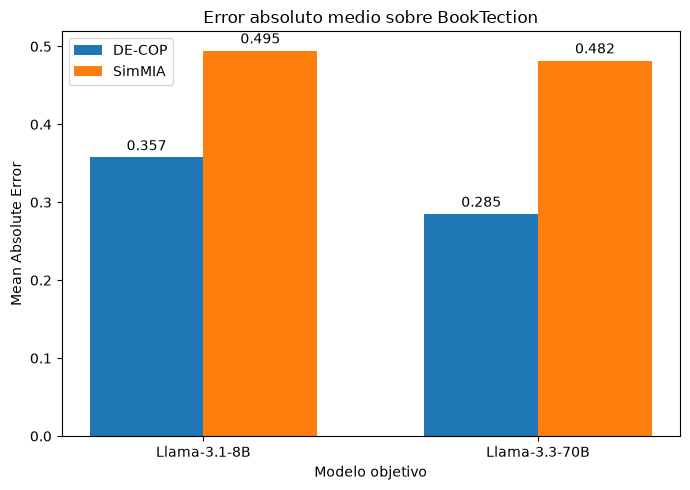

PNG: /Users/florenciazoffi/Desktop/code/sietesemestre/nlp/NLP_Proyecto_Final/simmia_decop/figures/mae_booktection_decop_vs_simmia.png
PDF: /Users/florenciazoffi/Desktop/code/sietesemestre/nlp/NLP_Proyecto_Final/simmia_decop/figures/mae_booktection_decop_vs_simmia.pdf


In [18]:
# ---------------------------------------------------------
# Mean Absolute Error
# ---------------------------------------------------------

mae_summary = pd.DataFrame([
    {
        "Modelo": "Llama-3.1-8B",
        "DE-COP": float(decop_8["mean_absolute_error"]),
        "SimMIA": float(simmia_8["mean_absolute_error"]),
    },
    {
        "Modelo": "Llama-3.3-70B",
        "DE-COP": float(decop_70["mean_absolute_error"]),
        "SimMIA": float(simmia_70["mean_absolute_error"]),
    },
])

display(mae_summary)

models = mae_summary["Modelo"]

decop_mae = mae_summary["DE-COP"]
simmia_mae = mae_summary["SimMIA"]

x = np.arange(len(models))
width = 0.34

fig, ax = plt.subplots(figsize=(7,5))

bars1 = ax.bar(
    x - width/2,
    decop_mae,
    width,
    label="DE-COP",
)

bars2 = ax.bar(
    x + width/2,
    simmia_mae,
    width,
    label="SimMIA",
)

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.set_ylabel("Mean Absolute Error")
ax.set_xlabel("Modelo objetivo")
ax.set_title("Error absoluto medio sobre BookTection")
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.005,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

plt.tight_layout()

png_path = FIGURES_DIR / "mae_booktection_decop_vs_simmia.png"
pdf_path = FIGURES_DIR / "mae_booktection_decop_vs_simmia.pdf"

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

plt.show()

print("PNG:", png_path)
print("PDF:", pdf_path)

In [16]:
wikimia_summary_df = pd.DataFrame([
    {
        "Método": "DE-COP",
        "Modelo": decop_wikimia_metrics["model"],
        "Dataset": decop_wikimia_metrics["split"],
        "AUC": float(decop_wikimia_metrics["auc"]),
        "TPR@5%FPR": (
            float(decop_wikimia_metrics["tpr_at_5_fpr"])
            if "tpr_at_5_fpr" in decop_wikimia_metrics.index
            else None
        ),
        "Muestras": int(decop_wikimia_metrics["n_samples"]),
    },
])

display(wikimia_summary_df)

,Método,Modelo,Dataset,AUC,TPR@5%FPR,Muestras
0,DE-COP,llama-3.1-8b-instant,WikiMIA_length128,0.54865,0.02,200
